<a href="https://colab.research.google.com/github/StaryDron/PigPostureComputerVision/blob/main/EfficientNet_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dominika2024","key":"5b70a7c216956767dcbe2e100185e54d"}'}

In [2]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [3]:
!kaggle competitions download -c multi-view-pig-posture-recognition

100% 1.82G/1.82G [00:49<00:00, 39.6MB/s]



In [13]:
!ls data/multiview_pig_posture_recognition

pig_posture_classes.txt  test.csv     train1.csv     train2.csv
sample_submission.csv	 test_images  train1_images  train2_images


In [6]:
!unzip multi-view-pig-posture-recognition.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_135939.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140259.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140439.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140759.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_140940.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141300.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141439.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141759.jpg  
  inflating: data/multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141940.jpg  
  inflating: data/multiview_pig

In [14]:
import pandas as pd

df = pd.read_csv("data/multiview_pig_posture_recognition/train1.csv")
df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [15]:
import os
import ast
import copy
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [16]:
CLASS_NAMES = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying",
}

BASE_DIR = "data/multiview_pig_posture_recognition"

TRAIN2_CSV = os.path.join(BASE_DIR, "train2.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")

train2 = pd.read_csv(TRAIN2_CSV)
test = pd.read_csv(TEST_CSV)

train = train2.copy()
train["source"] = "train2"
test["source"] = "test"

train["bbox_parsed"] = train["bbox"].apply(ast.literal_eval)
test["bbox_parsed"] = test["bbox"].apply(ast.literal_eval)

train["class_name"] = train["class_id"].map(CLASS_NAMES)

print("Train rows:", len(train))
print("Train images:", train["image_id"].nunique())
print(train["class_name"].value_counts())

Train rows: 23450
Train images: 3150
class_name
Standing               9928
Sternal_lying          6309
Lateral_lying_right    3435
Lateral_lying_left     3083
Sitting                 695
Name: count, dtype: int64


In [17]:
def crop_with_padding(image, bbox, padding=0.12, make_square=True):
    img_w, img_h = image.size
    x, y, w, h = map(float, bbox)

    pad_x = w * padding
    pad_y = h * padding

    x1 = x - pad_x
    y1 = y - pad_y
    x2 = x + w + pad_x
    y2 = y + h + pad_y

    if make_square:
        crop_w = x2 - x1
        crop_h = y2 - y1
        side = max(crop_w, crop_h)

        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        x1 = cx - side / 2
        x2 = cx + side / 2
        y1 = cy - side / 2
        y2 = cy + side / 2

    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(img_w, int(round(x2)))
    y2 = min(img_h, int(round(y2)))

    if x2 <= x1:
        x2 = min(img_w, x1 + 1)
    if y2 <= y1:
        y2 = min(img_h, y1 + 1)

    return image.crop((x1, y1, x2, y2))

In [18]:
def load_image(image_id, source):
    if source == "train1":
        folder = "train1_images"
    elif source == "train2":
        folder = "train2_images"
    elif source == "test":
        folder = "test_images"
    else:
        raise ValueError(f"Unknown source: {source}")

    path = os.path.join(BASE_DIR, folder, image_id)
    return Image.open(path).convert("RGB")

In [19]:
class PigPostureDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = load_image(row["image_id"], row["source"])
        crop = crop_with_padding(
            image,
            row["bbox_parsed"],
            padding=0.12,
            make_square=True
        )

        if self.transform:
            crop = self.transform(crop)

        if self.is_test:
            return crop, row["row_id"]

        label = int(row["class_id"])
        return crop, label

In [20]:
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.05, p=0.3):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            tensor = tensor + torch.randn_like(tensor) * self.std + self.mean
            tensor = torch.clamp(tensor, 0.0, 1.0)
        return tensor

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    AddGaussianNoise(p=0.3),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.08),
        ratio=(0.75, 1.33),
        value="random"
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(train, y=train["class_id"], groups=train["image_id"])
)

train_df = train.iloc[train_idx].reset_index(drop=True)
val_df = train.iloc[val_idx].reset_index(drop=True)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))

print("Train unique images:", train_df["image_id"].nunique())
print("Val unique images:", val_df["image_id"].nunique())

print("Overlap images:", len(set(train_df["image_id"]) & set(val_df["image_id"])))

Train rows: 18802
Val rows: 4648
Train unique images: 2520
Val unique images: 630
Overlap images: 0


In [23]:
train_targets = train_df["class_id"].values

class_counts = np.bincount(train_targets, minlength=len(CLASS_NAMES))
print("Class counts:", class_counts)

class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = np.array([class_weights[y] for y in train_targets])

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

Class counts: [2459 2743  571 7965 5064]


In [24]:
BATCH_SIZE = 32

train_dataset = PigPostureDataset(train_df, transform=train_transform)
val_dataset = PigPostureDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [25]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([4, 3, 0, 2, 2, 3, 4, 3, 3, 1])


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [27]:
num_classes = len(CLASS_NAMES)

weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = models.efficientnet_v2_s(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 164MB/s]


In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

In [29]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, f1

In [30]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, f1, all_labels, all_preds

In [32]:
EPOCHS = 8

best_f1 = 0
best_state = None
history = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader)

    scheduler.step(val_f1)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

        torch.save({
            "model_state_dict": best_state,
            "class_names": CLASS_NAMES,
            "best_f1": best_f1,
        }, "best_efficientnetv2_s_pigs.pt")

print("Najlepsze val macro-F1:", best_f1)

  0%|          | 0/588 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

Epoch 1/8 | train loss 0.2038 acc 0.9309 f1 0.9308 | val loss 0.2041 acc 0.9286 f1 0.8999


  0%|          | 0/588 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

...

  0%|          | 0/146 [00:00<?, ?it/s]

Epoch 7/8 | train loss 0.0954 acc 0.9689 f1 0.9688 | val loss 0.1884 acc 0.9479 f1 0.9277


  0%|          | 0/588 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

Epoch 8/8 | train loss 0.0851 acc 0.9702 f1 0.9702 | val loss 0.1780 acc 0.9479 f1 0.9251
Najlepsze val macro-F1: 0.9277313629921787


In [34]:
model.load_state_dict(best_state)

val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, val_loader)

target_names = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES))]

print("Val accuracy:", val_acc)
print("Val macro F1:", val_f1)

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names
))

  0%|          | 0/146 [00:00<?, ?it/s]

Val accuracy: 0.947934595524957
Val macro F1: 0.9277313629921787
                     precision    recall  f1-score   support

 Lateral_lying_left       0.92      0.93      0.92       624
Lateral_lying_right       0.89      0.93      0.91       692
            Sitting       0.90      0.90      0.90       124
           Standing       0.99      0.99      0.99      1963
      Sternal_lying       0.93      0.91      0.92      1245

           accuracy                           0.95      4648
          macro avg       0.93      0.93      0.93      4648
       weighted avg       0.95      0.95      0.95      4648



In [35]:
from google.colab import files
files.download("best_efficientnetv2_s_pigs.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

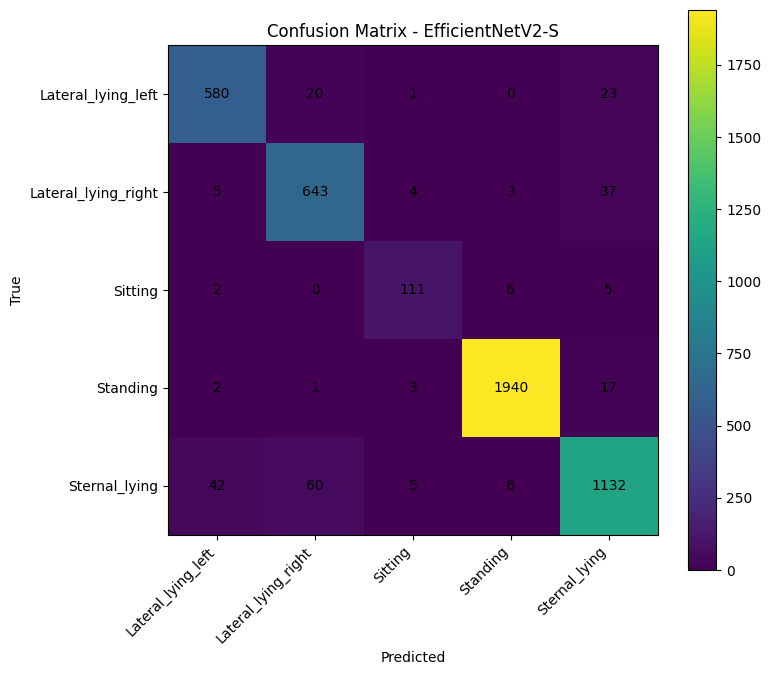

In [36]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Confusion Matrix - EfficientNetV2-S")
plt.xticks(range(num_classes), target_names, rotation=45, ha="right")
plt.yticks(range(num_classes), target_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()